# Comprehensive Experiments Summary: Cost-Sensitive Predictive Modeling

Documentation of all tested approaches for feature selection and modeling.
**Objective:** Maximize the metric Profit = (TP × 10) - (FP × 5) - (num_vars × 200)

In [2]:
import sys
sys.path.append('../')
from src.data_loader import load_project_data
from src.evaluation import calculate_profit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data loading and train/validation split

In [ ]:
# Load data
X_train_full, y_train_full, X_test = load_project_data()
y_full = y_train_full.iloc[:, 0]

# Reproducible train/validation split (20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_full, test_size=0.2, random_state=67, stratify=y_full
)

print("Data loaded:")
print(f"   Train: {X_train.shape} | Validation: {X_val.shape} | Test: {X_test.shape}")
print(f"   Target class distribution: {y_train.value_counts().to_dict()}")

# Business parameters
PROFIT_THRESHOLD = 1.0 / 3.0  # threshold used by select_offer_indices
MAX_OFFERS = 1000
FEATURE_COST = 200

2026-06-07 22:02:50 - INFO - Data loaded — X_train: (5000, 500), y_train: (5000, 1), X_test: (5000, 500)


X_train_full shape: (5000, 500)
y_full shape: (5000,)
Data loaded:
   Train: (4000, 500) | Validation: (1000, 500) | Test: (5000, 500)
   Target class distribution: {0: 2010, 1: 1990}


## 2. Helper functions for model evaluation and result logging

In [5]:
def evaluate_model(model, X_train, X_val, y_train, y_val, features_list, approach_name):
    """Evaluate a model and return summary results."""
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1]
    
    # Accuracy
    train_acc = (y_train_pred == y_train).mean()
    val_acc = (y_val_pred == y_val).mean()
    
    # Profit (using src.evaluation)
    profit = calculate_profit(
        y_true=y_val,
        y_pred_proba=y_val_proba,
        num_vars=len(features_list),
        debug=False
    )
    
    return {
        'Approach': approach_name,
        'Num_Variables': len(features_list),
        'Train_Accuracy': train_acc,
        'Val_Accuracy': val_acc,
        'Profit_EUR': profit,
        'Variables': features_list,
        'Model': model
    }

# Storage for all notebook experiment results
results_log = []

## 3. Experiment 1: LogisticRegression on top correlations

In [6]:
# Compute correlations with the target
df_eda = pd.concat([X_train, y_train], axis=1)
correlations = df_eda.corr()[y_train.name].drop(y_train.name)
top_correlations_1 = correlations.abs().sort_values(ascending=False).head(1)
top_correlations_5 = correlations.abs().sort_values(ascending=False).head(5)

print(f"Top 1 feature (correlation): {top_correlations_1.index[0]} ({top_correlations_1.values[0]:.3f})")
print(f"Top 5 features (correlation): {list(top_correlations_5.index)}")

# Exp 1a: Top 1 feature
features_exp1a = list(top_correlations_1.index)
model_exp1a = LogisticRegression(random_state=67, max_iter=1000)
result_exp1a = evaluate_model(
    model_exp1a, 
    X_train[features_exp1a], X_val[features_exp1a], 
    y_train, y_val, 
    features_exp1a, 
    "LR - Top 1 feature"
)
results_log.append(result_exp1a)
print(f"Exp 1a result: {result_exp1a}")

# Exp 1b: Top 5 features
features_exp1b = list(top_correlations_5.index)
model_exp1b = LogisticRegression(random_state=67, max_iter=1000)
result_exp1b = evaluate_model(
    model_exp1b,
    X_train[features_exp1b], X_val[features_exp1b],
    y_train, y_val,
    features_exp1b,
    "LR - Top 5 features"
)
results_log.append(result_exp1b)
print(f"Exp 1b result: {result_exp1b}")

Top 1 feature (correlation): V390 (0.121)
Top 5 features (correlation): ['V390', 'V224', 'V161', 'V32', 'V175']
Exp 1a result: {'Approach': 'LR - Top 1 feature', 'Num_Variables': 1, 'Train_Accuracy': np.float64(0.539), 'Val_Accuracy': np.float64(0.533), 'Profit_EUR': 2295.0, 'Variables': ['V390'], 'Model': LogisticRegression(max_iter=1000, random_state=67)}
Exp 1b result: {'Approach': 'LR - Top 5 features', 'Num_Variables': 5, 'Train_Accuracy': np.float64(0.5755), 'Val_Accuracy': np.float64(0.557), 'Profit_EUR': 1490.0, 'Variables': ['V390', 'V224', 'V161', 'V32', 'V175'], 'Model': LogisticRegression(max_iter=1000, random_state=67)}


## 4. Experiment 2: LogisticRegression with L1 and feature selection

In [7]:
# LogisticRegression with L1 regularization on all features
model_l1 = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, l1_ratio=1.0, C=0.01, random_state=67)
model_l1.fit(X_train, y_train)

# Extract features with non-zero coefficients
non_zero_indices = np.where(model_l1.coef_[0] != 0)[0]
features_exp2 = X_train.columns[non_zero_indices].tolist()

print(f"L1 selected {len(features_exp2)} features: {features_exp2}")

# Evaluate L1 model
result_exp2 = evaluate_model(
    LogisticRegression(penalty='l1', solver='saga', max_iter=1000, l1_ratio=1.0, C=0.01, random_state=67),
    X_train[features_exp2], X_val[features_exp2],
    y_train, y_val,
    features_exp2,
    "LR - L1 Regularization"
)
results_log.append(result_exp2)
print(f"Exp 2 result: Profit={result_exp2['Profit_EUR']:.0f} EUR, Variables={result_exp2['Num_Variables']}")

L1 selected 52 features: ['V3', 'V24', 'V32', 'V34', 'V50', 'V64', 'V86', 'V88', 'V94', 'V98', 'V99', 'V107', 'V108', 'V152', 'V153', 'V161', 'V162', 'V174', 'V175', 'V199', 'V203', 'V205', 'V213', 'V220', 'V221', 'V224', 'V229', 'V231', 'V256', 'V268', 'V273', 'V282', 'V295', 'V312', 'V317', 'V328', 'V329', 'V341', 'V345', 'V346', 'V365', 'V378', 'V383', 'V390', 'V393', 'V419', 'V422', 'V424', 'V428', 'V433', 'V440', 'V495']
Exp 2 result: Profit=-7955 EUR, Variables=52


## 5. Experiment 3: Boruta for feature selection

In [9]:
try:
    from boruta import BorutaPy
    
    # Feature selection with Boruta
    rf_estimator = RandomForestClassifier(
        n_estimators=100, random_state=67, n_jobs=-1, 
        class_weight='balanced', max_depth=5
    )
    
    boruta = BorutaPy(rf_estimator, n_estimators='auto', random_state=67, max_iter=50)
    boruta.fit(X_train.values, y_train.values)
    
    confirmed_features = X_train.columns[boruta.support_].tolist()
    tentative_features = X_train.columns[boruta.support_weak_].tolist()
    
    print(f"Confirmed features ({len(confirmed_features)}): {confirmed_features}")
    print(f"Tentative features ({len(tentative_features)}): {tentative_features}")
    
    # Use only confirmed features
    features_exp3 = confirmed_features
    
    # Evaluate model on Boruta features
    result_exp3 = evaluate_model(
        LogisticRegression(random_state=67, max_iter=1000),
        X_train[features_exp3], X_val[features_exp3],
        y_train, y_val,
        features_exp3,
        "LR - Boruta Confirmed"
    )
    results_log.append(result_exp3)
    print(f"Exp 3 result: Profit={result_exp3['Profit_EUR']:.0f} EUR, Variables={result_exp3['Num_Variables']}")
    
except ImportError:
    print("Boruta is not installed, skipping this experiment")

Confirmed features (28): ['V5', 'V11', 'V32', 'V46', 'V60', 'V117', 'V160', 'V161', 'V175', 'V176', 'V191', 'V199', 'V215', 'V224', 'V227', 'V255', 'V262', 'V265', 'V309', 'V313', 'V329', 'V342', 'V345', 'V380', 'V390', 'V416', 'V443', 'V483']
Tentative features (0): []
Exp 3 result: Profit=-3160 EUR, Variables=28


## 6. Experiment 4: HistGradientBoosting on Boruta features

In [10]:
try:
    # HistGradientBoosting on Boruta features
    model_hgb = HistGradientBoostingClassifier(
        max_iter=50, max_depth=3, min_samples_leaf=100,
        l2_regularization=2.0, learning_rate=0.05, random_state=67
    )
    
    result_exp4 = evaluate_model(
        model_hgb,
        X_train[features_exp3], X_val[features_exp3],
        y_train, y_val,
        features_exp3,
        "HistGradientBoosting - Boruta"
    )
    results_log.append(result_exp4)
    print(f"Exp 4 result: Profit={result_exp4['Profit_EUR']:.0f} EUR, Variables={result_exp4['Num_Variables']}")
except NameError:
    print("Boruta was not available, skipping HistGradientBoosting on Boruta features")

Exp 4 result: Profit=-3120 EUR, Variables=28


## 7. Summary table: accuracy, profit, number of variables

In [11]:
# Load results from experiment_results.csv (produced by run_experiments.py)
import os
results_csv_path = '../experiment_results.csv'
if os.path.exists(results_csv_path):
    exp_results = pd.read_csv(results_csv_path)
    print("\nResults from automated experiments (run_experiments.py):")
    print(exp_results[['name', 'profit', 'features']].to_string())
    
    # Parse features string to list
    exp_results['num_features'] = exp_results['features'].apply(
        lambda x: len(eval(x)) if isinstance(x, str) else 0
    )
    print(f"\nBest result: {exp_results.loc[exp_results['profit'].idxmax(), 'name']} with profit {exp_results['profit'].max():.0f} EUR")

# Create DataFrame from notebook experiments
results_df = pd.DataFrame(results_log)
results_df = results_df[['Approach', 'Num_Variables', 'Train_Accuracy', 'Val_Accuracy', 'Profit_EUR']].sort_values('Profit_EUR', ascending=False)

print("\n\nSummary table of all notebook experiments:")
print(results_df.to_string(index=False))
print(f"\nWINNER: {results_df.iloc[0]['Approach']} - Profit: {results_df.iloc[0]['Profit_EUR']:.0f} EUR")



Summary table of all notebook experiments:
                     Approach  Num_Variables  Train_Accuracy  Val_Accuracy  Profit_EUR
           LR - Top 1 feature              1         0.53900         0.533      2295.0
          LR - Top 5 features              5         0.57550         0.557      1490.0
HistGradientBoosting - Boruta             28         0.71875         0.646     -3120.0
        LR - Boruta Confirmed             28         0.59775         0.578     -3160.0
       LR - L1 Regularization             52         0.60950         0.561     -7955.0

WINNER: LR - Top 1 feature - Profit: 2295 EUR


## 8. Comparative visualizations of models and feature selection

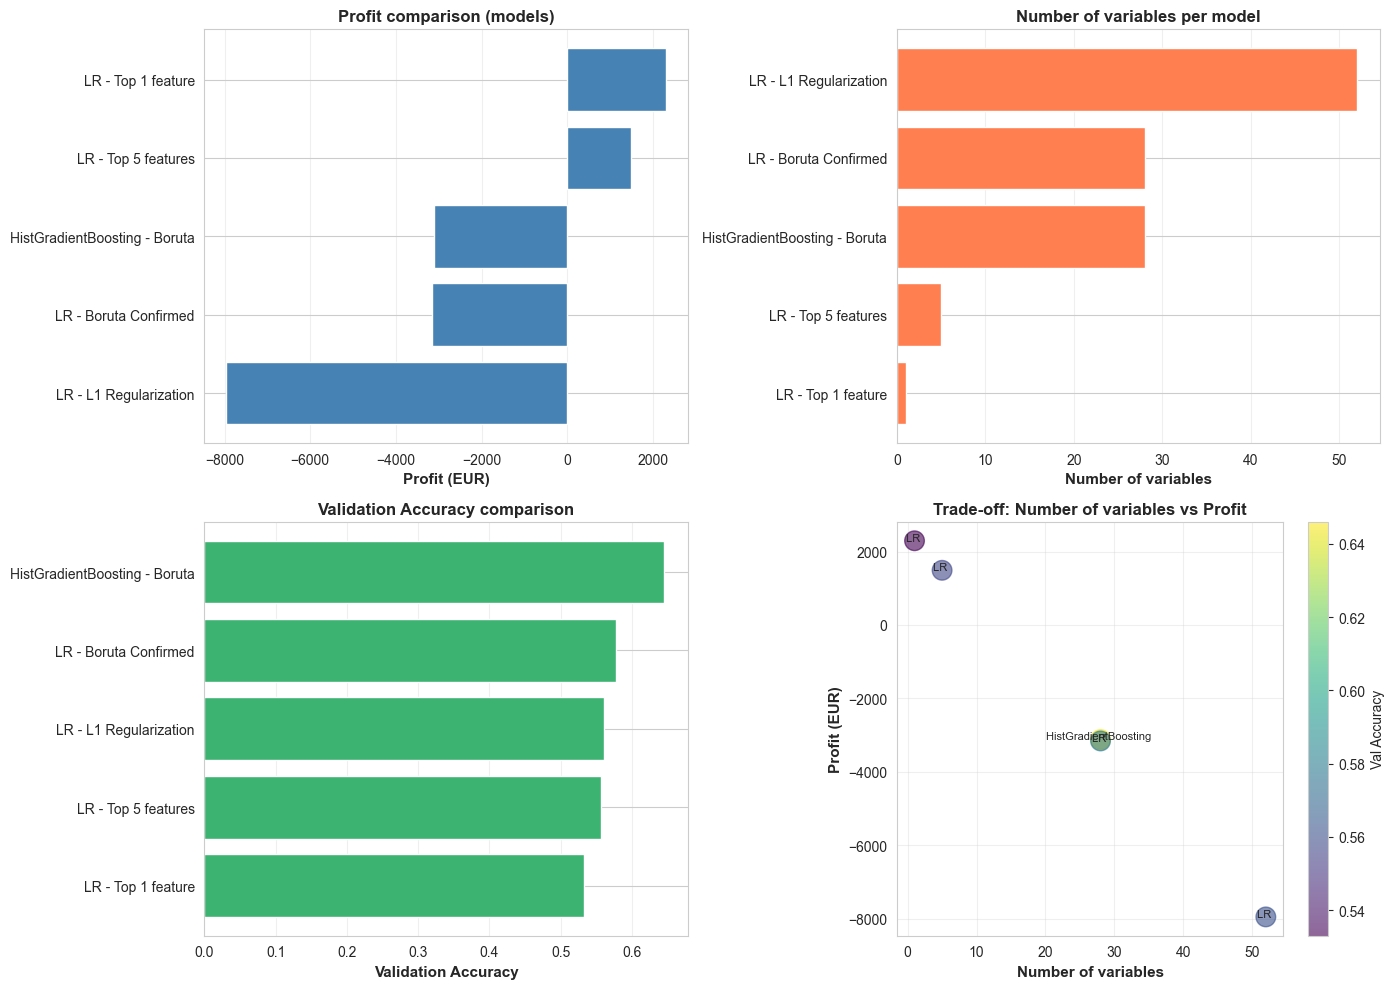

Visualizations generated.


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Profit comparison
ax1 = axes[0, 0]
results_df_sorted = results_df.sort_values('Profit_EUR', ascending=True)
ax1.barh(results_df_sorted['Approach'], results_df_sorted['Profit_EUR'], color='steelblue')
ax1.set_xlabel('Profit (EUR)', fontsize=11, fontweight='bold')
ax1.set_title('Profit comparison (models)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Number of variables
ax2 = axes[0, 1]
results_df_sorted2 = results_df.sort_values('Num_Variables', ascending=True)
ax2.barh(results_df_sorted2['Approach'], results_df_sorted2['Num_Variables'], color='coral')
ax2.set_xlabel('Number of variables', fontsize=11, fontweight='bold')
ax2.set_title('Number of variables per model', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Validation Accuracy
ax3 = axes[1, 0]
results_df_sorted3 = results_df.sort_values('Val_Accuracy', ascending=True)
ax3.barh(results_df_sorted3['Approach'], results_df_sorted3['Val_Accuracy'], color='mediumseagreen')
ax3.set_xlabel('Validation Accuracy', fontsize=11, fontweight='bold')
ax3.set_title('Validation Accuracy comparison', fontsize=12, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Scatter: Number of variables vs Profit
ax4 = axes[1, 1]
scatter = ax4.scatter(results_df['Num_Variables'], results_df['Profit_EUR'], 
                    s=200, alpha=0.6, c=results_df['Val_Accuracy'], cmap='viridis')
for idx, row in results_df.iterrows():
    ax4.annotate(row['Approach'].split('-')[0], 
                (row['Num_Variables'], row['Profit_EUR']),
                fontsize=8, ha='center')
ax4.set_xlabel('Number of variables', fontsize=11, fontweight='bold')
ax4.set_ylabel('Profit (EUR)', fontsize=11, fontweight='bold')
ax4.set_title('Trade-off: Number of variables vs Profit', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Val Accuracy', fontsize=10)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualizations generated.")

# Conclusions

Overall this notebook was a playground for us to initially test some models and see their results, but it didn't provide us with interesting results other than the conclusion, that the less variables used the better was the profit made by the models.